# 1. Información del Proyecto
- Nombre del proyecto: Titanic 

- Descripción breve: On April 15, 1912, during her maiden voyage, the widely considered “unsinkable” RMS Titanic sank after colliding with an iceberg. Unfortunately, there weren’t enough lifeboats for everyone on board, resulting in the death of 1502 out of 2224 passengers and crew.

- Objetivo principal: to build a predictive model that answers the question: “what sorts of people were more likely to survive?” using passenger data (ie name, age, gender, socio-economic class, etc).

- Preguntas a responder: what sorts of people were more likely to survive?

## 2. Fuente y Descripción de los Datos
- Archivos utilizados: Titanic-Dataset.csv
- Procedencia de los datos: Kaggle.com
- tipos de datos: 
    - Survival 	0 = No, 1 = Yes
    - pclass    1 = 1st, 2 = 2nd, 3 = 3rd
    - sex       Male / Female
    - Age	    Age in years
    - sibsp	    # of siblings / spouses aboard the Titanic	
    - parch	    # of parents / children aboard the Titanic	
    - ticket	Ticket number
    - fare	    Passenger fare
    - cabin	    Cabin number
    - embarked	Port of Embarkation:	C = Cherbourg, Q = Queenstown, S = Southampton

In [205]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

## 3. Carga de Datos

In [206]:
df = pd.read_csv("DataScience_Real_Project\data\Titanic\Titanic-Dataset.csv")
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\juan_\AppData\Local\Temp\ipykernel_33664\3236236211.py:1: SyntaxWarning: invalid escape sequence '\d'
  df = pd.read_csv("DataScience_Real_Project\data\Titanic\Titanic-Dataset.csv")


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 4. Exploración Inicial (EDA)
- Vista general
- Estadísticas descriptivas
- Distribuciones
- Outliers
- Faltantes

In [207]:
df.shape

(891, 12)

In [208]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [209]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [210]:
df.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

In [211]:
age = df['Age']
fare = df['Fare']
survived = df['Survived']
pclass = df['Pclass']
sex= df['Sex']
embarked = df['Embarked']
ticket = df['Ticket']

# Distribución de edades

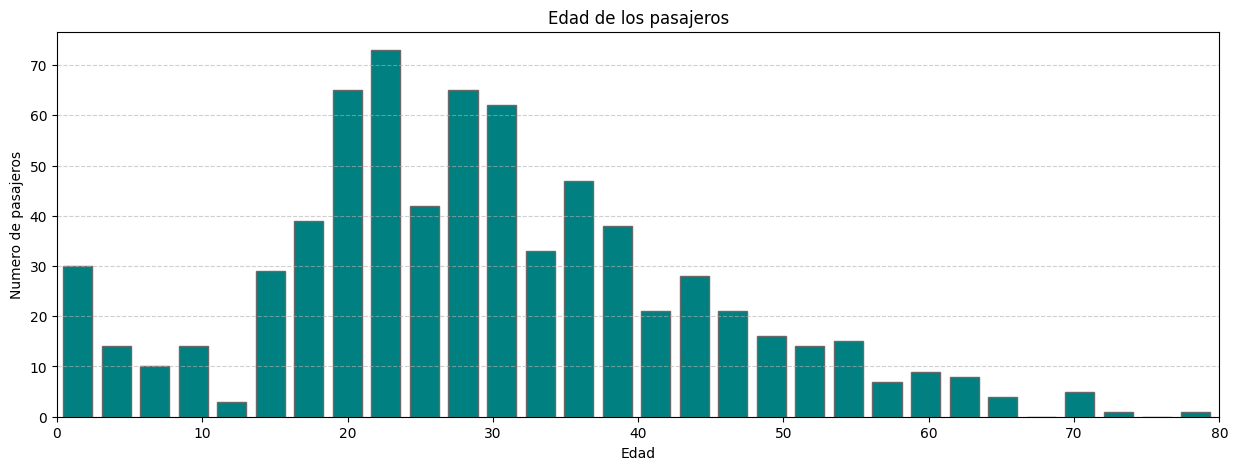

In [212]:
plt.figure(figsize=(15,5))
plt.hist(age.dropna(), bins= 30, width=2, color= 'teal', edgecolor='dimgray')
plt.xlim(0,80)
plt.grid(alpha= .6, axis='y', linestyle='--')
plt.title('Edad de los pasajeros')
plt.xlabel('Edad')
plt.ylabel('Numero de pasajeros')

plt.show()

# Supervivencia total

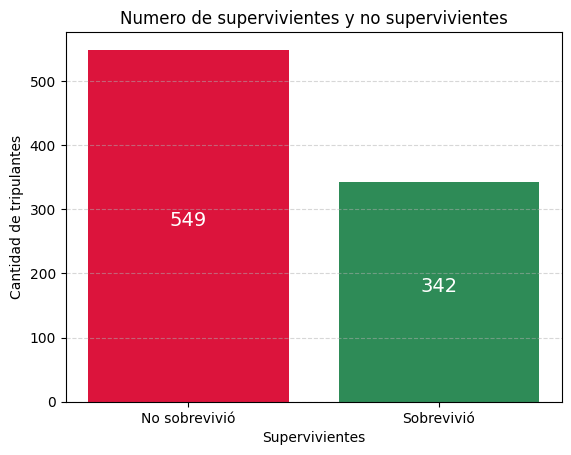

In [213]:
counts = df["Survived"].value_counts().sort_values()
colors = ['seagreen','crimson']
bars= plt.bar(counts.index, counts.values, color = colors)

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y/2, int(y),
             ha='center', fontsize= 14, color= 'white')
    

plt.xticks([0,1], ["No sobrevivió","Sobrevivió"])
plt.title('Numero de supervivientes y no supervivientes')
plt.ylabel('Cantidad de tripulantes')
plt.xlabel('Supervivientes')
plt.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.show()

# Supervivencia por sexo

In [214]:
sup_sexo = df.groupby(['Survived','Sex']).size().unstack(fill_value=0)
sup_sexo

Sex,female,male
Survived,,
0,81,468
1,233,109


<function matplotlib.pyplot.show(close=None, block=None)>

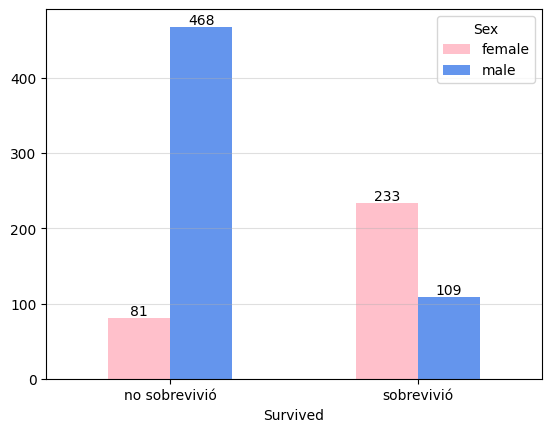

In [215]:
colors = ['cornflowerblue' if x == 'male' else 'pink' for x in sup_sexo]

ax = sup_sexo.plot(kind= 'bar', color=colors)
for etiqueta in ax.patches:
    x = etiqueta.get_x() + etiqueta.get_width() / 2
    y = etiqueta.get_y() + etiqueta.get_height()
    altura = int(etiqueta.get_height())
    if altura > 0:  # solo mostrar si hay valor
        ax.annotate(str(altura), (x, y), ha='center', va='bottom')

plt.grid(alpha=.4, axis='y')
plt.xticks([0,1],['no sobrevivió', 'sobrevivió'], rotation=0)
plt.show

# Supervivencia por clase

In [216]:
conteo = df.groupby(['Pclass', 'Survived']).size().unstack(fill_value=0)
conteo

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


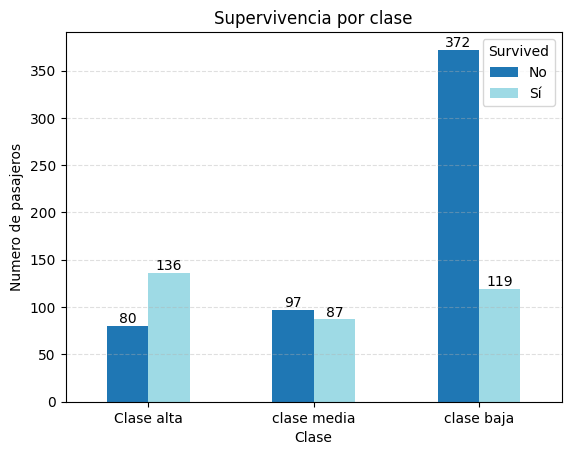

In [217]:
ax = conteo.plot(kind= 'bar',stacked=False, colormap='tab20')
for etiqueta in ax.patches:
    # Obtener coordenadas y altura de cada barra
    x = etiqueta.get_x() + etiqueta.get_width() / 2
    y = etiqueta.get_y() + etiqueta.get_height()
    altura = int(etiqueta.get_height())
    if altura > 0:  # solo mostrar si hay valor
        ax.annotate(str(altura), (x, y), ha='center', va='bottom')

plt.grid(alpha=.4, axis='y', linestyle='--')
plt.xlabel('Clase')
plt.ylabel('Numero de pasajeros')
plt.title('Supervivencia por clase')
plt.xticks([0,1,2],['Clase alta', 'clase media','clase baja'])
plt.xticks(rotation= 0)
plt.legend(title='Survived', labels=['No', 'Sí'])

# Edad vs Supervivencia

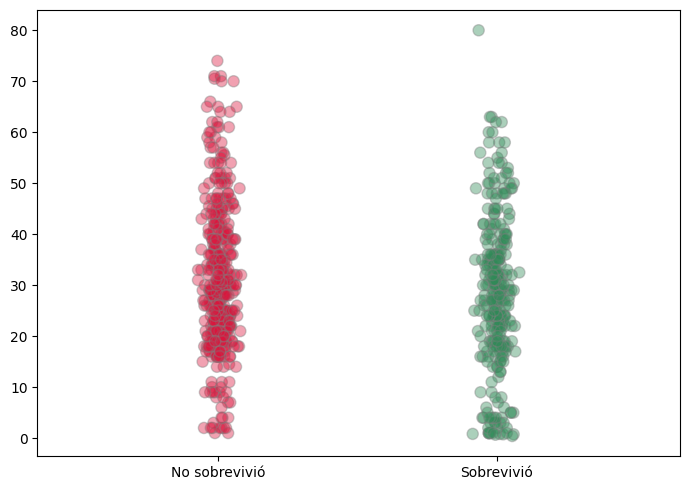

In [218]:
x = survived + np.random.normal(0, 0.03, len(survived)) 
colors = ['seagreen' if x == 1 else 'crimson' for x in survived.values ]

plt.figure(figsize=(7,5))
plt.scatter(x, age, s=65, alpha=.4, edgecolors="grey", color=colors)

plt.xticks([0,1], ["No sobrevivió","Sobrevivió"])
plt.yticks()
plt.margins(x=.5)
plt.tight_layout()

# Precio del boleto

In [219]:
clase1 = df[df['Pclass'] == 1]['Fare']
clase2 = df[df['Pclass'] == 2]['Fare']
clase3 = df[df['Pclass'] == 3]['Fare']


datos = [clase1,clase2,clase3]


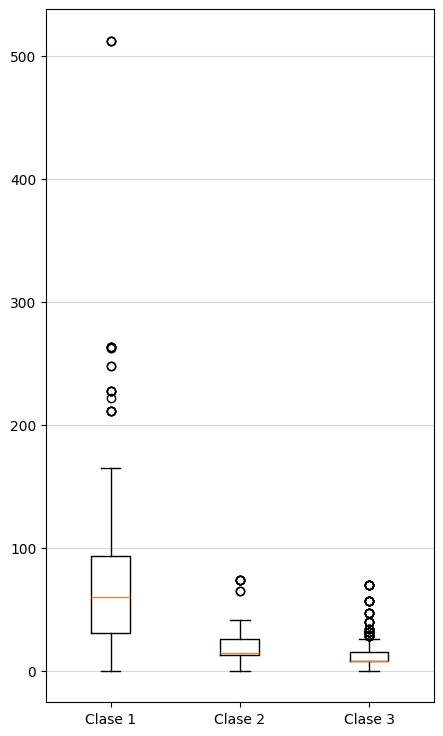

In [220]:
plt.figure(figsize=(5,9))
box = plt.boxplot(datos)
plt.xticks([1,2,3],['Clase 1','Clase 2','Clase 3'])
plt.grid(axis='y', alpha= .5)
plt.show()

## 6. Limpieza de Datos
- Tratamiento de faltantes
- Outliers
- Tipos de datos
- Normalización/codificación

### 6.1 Tratamiento de Faltantes

In [221]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [222]:
df['Cabin'] = df['Cabin'].fillna('Unknown')

In [223]:
df['Embarked'] = df['Embarked'].fillna('Unknown')

In [224]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin            0
Embarked         0
dtype: int64

### 6.3 Tipos de datos

In [225]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    object 
 11  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [226]:
df.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          148
Embarked         4
dtype: int64

### 6.4 normalización / codificación

In [227]:
df_coded = df

In [228]:
df_coded

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,Unknown,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,Unknown,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


## 7. Análisis Profundo
- Correlaciones
- Hallazgos

### 7.1 Correlaciones

In [229]:
corr = df_coded.corr(numeric_only=True)

<function matplotlib.pyplot.show(close=None, block=None)>

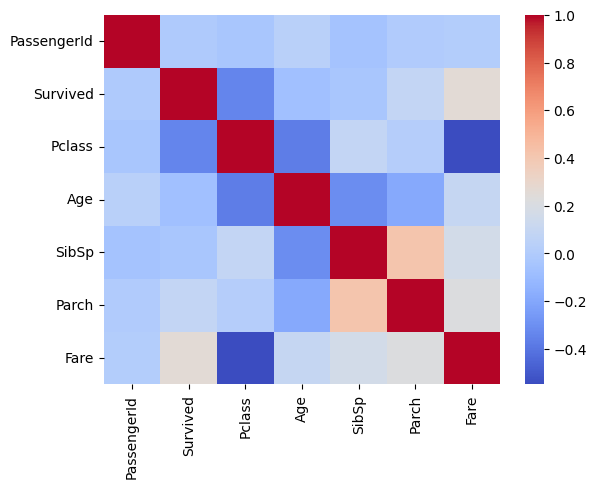

In [230]:
sns.heatmap(corr, cmap='coolwarm')
plt.show

### 7.2 Hallazgos

<function matplotlib.pyplot.show(close=None, block=None)>

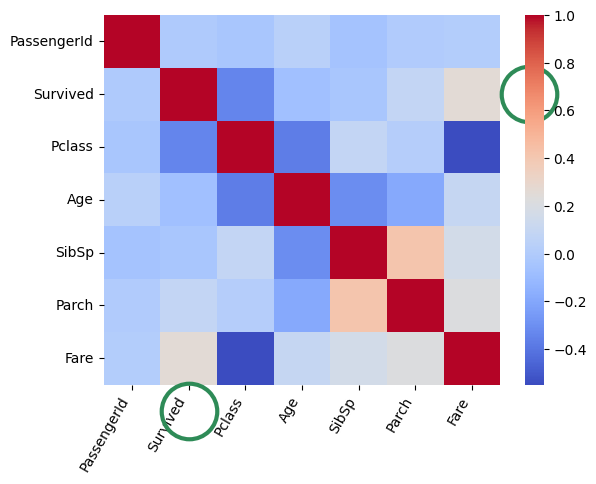

In [231]:
sns.heatmap(corr, cmap='coolwarm')
coords = [(7.5, 1.5), (1.5, 7.5)]  
for y, x in coords:
    plt.plot(x, y, marker= 'o', fillstyle= 'none', markersize= 40, markeredgewidth= 3, markeredgecolor= 'seagreen', clip_on=False ,alpha=1)
plt.xticks(rotation=60, ha='right')
plt.show

## 8. Ingeniería de Características
- Nuevas variables
- Transformaciones
- Selección de features

## 9. Preparación para Modelado
- Train/test
- Escalado
- Técnicas seleccionadas

### 9.1 Train/test

In [232]:
df_coded.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [233]:
df_coded

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,Unknown,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,Unknown,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [234]:
df_model = df_coded.drop(columns=['Name','Ticket', 'Cabin'])

In [235]:
X= df_model.drop(['Survived'], axis=1, inplace=False)
y= df_model['Survived']

In [236]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 9.2 Escalado

Este paso se hara despues para evitar Data Leakeage

### 9.3 Técnicas seleccionadas

#### Para este proyecto vamos a utilizar 3 modelos distintos: 

- Logistic Regression 
- Random Forest
- XGBoost

## 10. Modelado
- Modelos probados
- Justificación

### 10.1 Modelos

In [294]:
num_features = ["Age", "Fare", "SibSp", "Parch", "Pclass"]
cat_features = ["Sex", "Embarked"]

num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", num_transformer, num_features),
    ("cat", cat_transformer, cat_features)
])

model_pipeline_lr = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(random_state=42))
])

model_pipeline_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

model_pipeline_xg = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(random_state=42))
])


In [238]:
model_pipeline_lr.fit(X_train,y_train)
model_pipeline_rf.fit(X_train,y_train)
model_pipeline_xg.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [239]:
lr_pred = model_pipeline_lr.predict(X_test)
rf_pred = model_pipeline_rf.predict(X_test)
xg_pred = model_pipeline_xg.predict(X_test)

## 11. Evaluación
- Métricas
- Gráficas
- Comparación
- Interpretación

### 11.1 Metricas

In [240]:
lr_acc_score = accuracy_score(y_test, lr_pred)
lr_prec_score = precision_score(y_test, lr_pred)
lr_rec_score = recall_score(y_test, lr_pred)
lr_f1score = f1_score(y_test, lr_pred)

print(lr_acc_score)
print(lr_prec_score)
print(lr_rec_score)
print(lr_f1score)

0.8044692737430168
0.7746478873239436
0.7432432432432432
0.7586206896551724


In [241]:
rf_acc_score = accuracy_score(y_test, rf_pred)
rf_prec_score = precision_score(y_test, rf_pred)
rf_rec_score = recall_score(y_test, rf_pred)
rf_f1score = f1_score(y_test, rf_pred)

print(rf_acc_score)
print(rf_prec_score)
print(rf_rec_score)
print(rf_f1score)

0.8044692737430168
0.7746478873239436
0.7432432432432432
0.7586206896551724


In [242]:
xg_acc_score = accuracy_score(y_test, xg_pred)
xg_prec_score = precision_score(y_test, xg_pred)
xg_rec_score = recall_score(y_test, xg_pred)
xg_f1score = f1_score(y_test, xg_pred)

print(xg_acc_score)
print(xg_prec_score)
print(xg_rec_score)
print(xg_f1score)

0.8044692737430168
0.7746478873239436
0.7432432432432432
0.7586206896551724


### 11.2 Graficas

Text(0.5, 0, 'muestras')

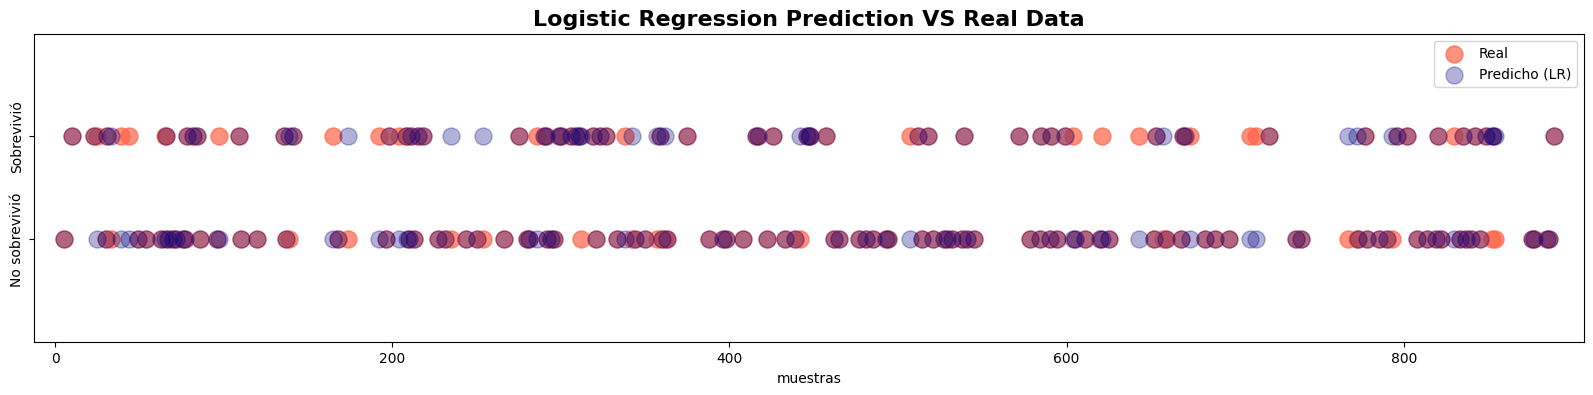

In [243]:
plt.figure(figsize=(20,4))
plt.scatter(y_test.index, y_test.values, s= 150, color= 'tomato', label= 'Real', alpha= .7)
plt.scatter(y_test.index, lr_pred, s=150,  color= 'navy', label= 'Predicho (LR)', alpha= .3)
plt.legend()
plt.yticks([0,1], ['No sobrevivió','Sobrevivió'])
plt.margins(y=1, x= 0.02)
plt.yticks(rotation=90, va='center', fontsize= 10)
plt.title('Logistic Regression Prediction VS Real Data', fontweight='bold',fontsize= 16)
plt.xlabel('muestras', fontsize=10)

Text(0.5, 0, 'muestras')

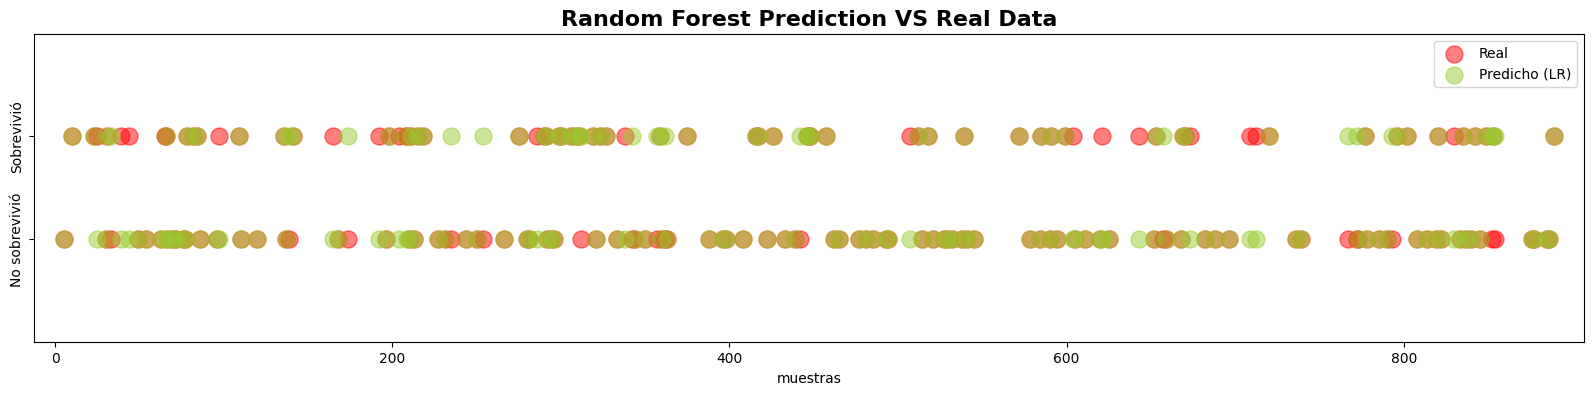

In [244]:
plt.figure(figsize=(20,4))
plt.scatter(y_test.index, y_test.values, s= 150, color= 'red', label= 'Real', alpha= 0.5)
plt.scatter(y_test.index, rf_pred, s=150,  color= 'yellowgreen', label= 'Predicho (LR)', alpha= 0.5)
plt.legend()
plt.yticks([0,1], ['No sobrevivió','Sobrevivió'])
plt.margins(y=1, x= 0.02)
plt.yticks(rotation=90, va='center', fontsize= 10)
plt.title('Random Forest Prediction VS Real Data', fontweight='bold',fontsize= 16)
plt.xlabel('muestras', fontsize=10)

Text(0.5, 0, 'muestras')

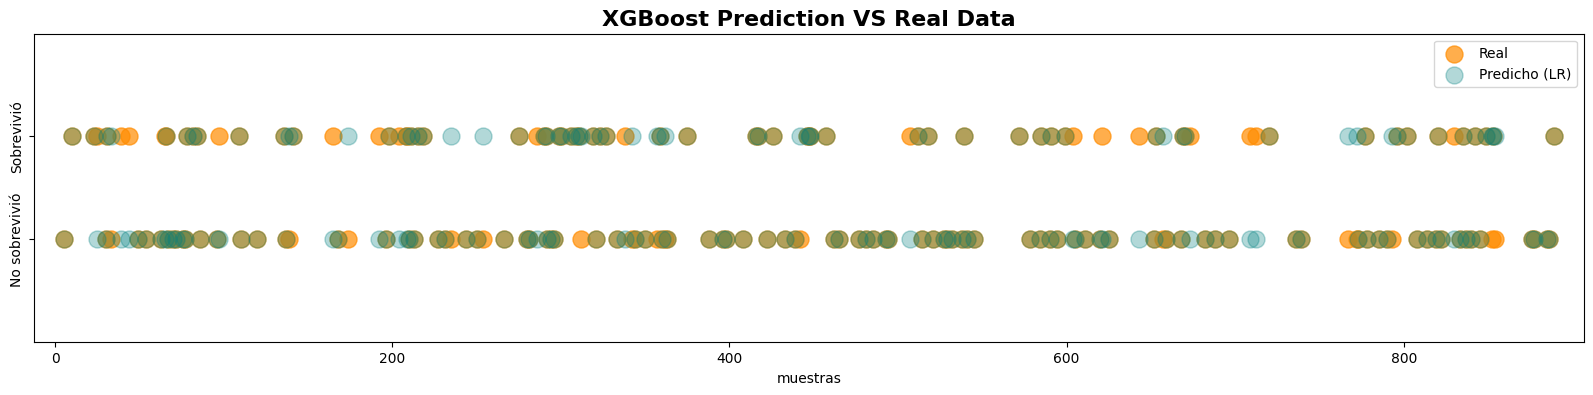

In [245]:
plt.figure(figsize=(20,4))
plt.scatter(y_test.index, y_test.values, s= 150, color= 'darkorange', label= 'Real', alpha= 0.7)
plt.scatter(y_test.index, xg_pred, s=150,  color= 'teal', label= 'Predicho (LR)', alpha= 0.3)
plt.legend()
plt.yticks([0,1], ['No sobrevivió','Sobrevivió'])
plt.margins(y=1, x= 0.02)
plt.yticks(rotation=90, va='center', fontsize= 10)
plt.title('XGBoost Prediction VS Real Data', fontweight='bold',fontsize= 16)
plt.xlabel('muestras', fontsize=10)

### 11.3 Comparacion

In [246]:
data = {
    'accuracy score' : [lr_acc_score, rf_acc_score, xg_acc_score],
    'precision score' : [lr_prec_score, rf_prec_score, xg_prec_score],
    'recall score ' : [lr_rec_score, rf_rec_score, xg_rec_score],
    'F1 score' : [lr_f1score, rf_f1score, xg_f1score]
    }

metricas = pd.DataFrame(data)

metricas.index = ['Lineal Regression', 'Random Forest', 'XGBoost']
metricas

,accuracy score,precision score,recall score,F1 score
Lineal Regression,0.804469,0.774648,0.743243,0.758621
Random Forest,0.804469,0.774648,0.743243,0.758621
XGBoost,0.804469,0.774648,0.743243,0.758621


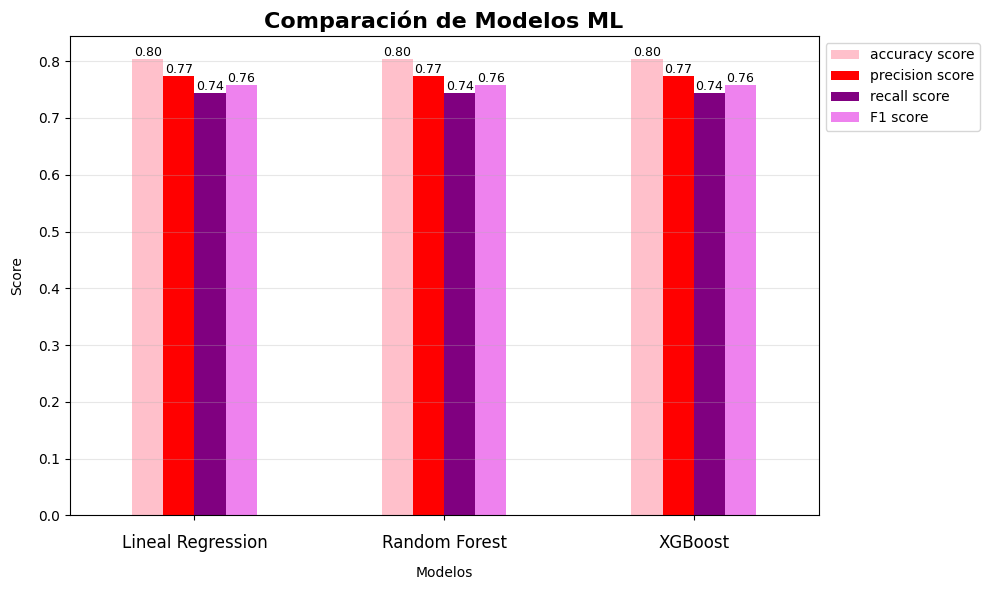

In [247]:
fig, ax = plt.subplots(figsize=(10,6))

colors = ['pink','red','purple','violet']

ax = metricas.plot(kind='bar', ax=ax, color=colors, legend=True)

# Iterar sobre los patches (barras) del axes
for bar in ax.patches:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height,
            f'{height:.2f}', ha='center', va='bottom', fontsize=9)

ax.set_title('Comparación de Modelos ML', fontsize=16, fontweight='bold')
ax.set_ylabel('Score', labelpad=10)
ax.set_xlabel('Modelos', labelpad=10)
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', alpha=0.3)
ax.set_xticklabels(['Lineal Regression','Random Forest','XGBoost'], fontsize=12)
ax.tick_params(axis='x', pad=10)
ax.legend(bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

### 11.4 Interpretación 

En la grafica se puede observar las metricas de cada uno de los modelos en los que se trabajó en este proyecto. El modelo de *Random Forest* fue el que mejores resultados dio. A continuación se harán mejoras en los parámetros para poder mejorar los aciertos del modelo. 

## 12. Ajuste y Optimización
- Validación cruzada
- Tuning
- Mejoras

### 12.1 Validación cruzada

In [248]:
from sklearn.model_selection import cross_val_score

In [255]:
rf_cv = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=100, random_state=42))
])

rf_cv.fit(X_train, y_train)
rf_cv_pred = rf_cv.predict(X_test)


In [259]:
lr_score_cv_acc = cross_val_score(estimator= model_pipeline_lr, X=X, y=y, cv=5, scoring='accuracy')
rf_score_cv_acc = cross_val_score(estimator= model_pipeline_rf, X=X, y=y, cv=5, scoring='accuracy')
xg_score_cv_acc = cross_val_score(estimator= model_pipeline_xg, X=X, y=y, cv=5, scoring='accuracy')

print(lr_score_cv_acc.mean())
print(rf_score_cv_acc.mean())
print(xg_score_cv_acc.mean())
print('\n')
print(lr_score_cv_acc.std())
print(rf_score_cv_acc.std())
print(xg_score_cv_acc.std())

0.8092335697696316
0.8092335697696316
0.8092335697696316


0.025849926369395752
0.025849926369395752
0.025849926369395752


In [260]:
cv_acc_data = {
    'CV accuracy mean' : [lr_score_cv_acc.mean(),rf_score_cv_acc.mean(),xg_score_cv_acc.mean()],
    'CV accuracy std' : [lr_score_cv_acc.std(),rf_score_cv_acc.std(),xg_score_cv_acc.std()]
    }

metricas_cv = pd.DataFrame(cv_acc_data)

metricas_cv.round(4)

,CV accuracy mean,CV accuracy std
0,0.8092,0.0258
1,0.8092,0.0258
2,0.8092,0.0258


In [263]:
lr_score_cv_recall = cross_val_score(estimator= model_pipeline_lr, X=X, y=y, cv=5, scoring='recall')
rf_score_cv_recall = cross_val_score(estimator= model_pipeline_rf, X=X, y=y, cv=5, scoring='recall')
xg_score_cv_recall = cross_val_score(estimator= model_pipeline_xg, X=X, y=y, cv=5, scoring='recall')

print(lr_score_cv_recall.mean())
print(rf_score_cv_recall.mean())
print(xg_score_cv_recall.mean())
print('\n')
print(lr_score_cv_recall.std())
print(rf_score_cv_recall.std())
print(xg_score_cv_recall.std())


0.7307757885763
0.7307757885763
0.7307757885763


0.06282713950488233
0.06282713950488233
0.06282713950488233


In [265]:
cv_rec_data = {
    'CV Recall mean' : [lr_score_cv_recall.mean(),rf_score_cv_recall.mean(),xg_score_cv_recall.mean()],
    'CV Recall std' : [lr_score_cv_recall.std(),rf_score_cv_recall.std(),xg_score_cv_recall.std()]
    }

metricas_cv = pd.DataFrame(cv_rec_data)

metricas_cv.round(4)

,CV Recall mean,CV Recall std
0,0.7308,0.0628
1,0.7308,0.0628
2,0.7308,0.0628


### Nota:
Se aplica scaling previo al Cross Validation con fines educativos.
En producción se recomienda Pipeline para evitar data leakage.

### 12.2 Tuning (Random Search / Grid Search)

Grid Search en Random Forest

In [266]:
from sklearn.model_selection import GridSearchCV

In [267]:
rf_model.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

In [275]:
parameters = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [2, 5, None],
    'model__min_samples_split': [2, 4]
}

gridsearch = GridSearchCV(model_pipeline_rf, parameters, cv=5, scoring='accuracy', verbose=2, n_jobs=1, return_train_score=True)
gridsearch

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [2, 5, ...], 'model__min_samples_split': [2, 4], 'model__n_estimators': [100, 200, ...]}"
,scoring,'accuracy'
,n_jobs,1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('num', ...), ('cat', ...)]"


In [276]:
gridsearch.fit(X_train, y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
[CV] END model__max_depth=2, model__min_samples_split=2, model__n_estimators=100; total time=   0.0s
[CV] END model__max_depth=2, model__min_samples_split=2, model__n_estimators=100; total time=   0.0s
[CV] END model__max_depth=2, model__min_samples_split=2, model__n_estimators=100; total time=   0.0s
[CV] END model__max_depth=2, model__min_samples_split=2, model__n_estimators=100; total time=   0.0s
[CV] END model__max_depth=2, model__min_samples_split=2, model__n_estimators=100; total time=   0.0s
[CV] END model__max_depth=2, model__min_samples_split=2, model__n_estimators=200; total time=   0.1s
[CV] END model__max_depth=2, model__min_samples_split=2, model__n_estimators=200; total time=   0.1s
[CV] END model__max_depth=2, model__min_samples_split=2, model__n_estimators=200; total time=   0.1s
[CV] END model__max_depth=2, model__min_samples_split=2, model__n_estimators=200; total time=   0.1s
[CV] END model__max_depth=2, m

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [2, 5, ...], 'model__min_samples_split': [2, 4], 'model__n_estimators': [100, 200, ...]}"
,scoring,'accuracy'
,n_jobs,1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('num', ...), ('cat', ...)]"


In [277]:
print(gridsearch.best_score_)
print(gridsearch.best_estimator_)
print(gridsearch.best_params_)

0.8286220821432089
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare', 'SibSp',
                                                   'Parch', 'Pclass']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncod

In [278]:
best_rf = gridsearch.best_estimator_

best_rf_pred = best_rf.predict(X_test)
best_rf_pred

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 1])

### Random Search 

In [279]:
from sklearn.model_selection import RandomizedSearchCV

In [280]:
xg_model.get_params()

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': None,
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': None,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': None,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': 42,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

In [295]:
randparam = {
    'model__n_estimators': [10, 50, 100, 200],
    'model__learning_rate': [0.1, 0.2, 0.5],
    'model__max_depth': [2, 5, 10],
    'model__subsample': [1, 0.5],
    'model__colsample_bytree': [1],
    'model__gamma': [1]
}

randomcv = RandomizedSearchCV(
    estimator=model_pipeline_xg,
    param_distributions=randparam,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    n_jobs=1,
    verbose=2,
    random_state=42
)

randomcv.fit(X_train, y_train)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END model__colsample_bytree=1, model__gamma=1, model__learning_rate=0.1, model__max_depth=2, model__n_estimators=100, model__subsample=1; total time=   0.0s
[CV] END model__colsample_bytree=1, model__gamma=1, model__learning_rate=0.1, model__max_depth=2, model__n_estimators=100, model__subsample=1; total time=   0.0s
[CV] END model__colsample_bytree=1, model__gamma=1, model__learning_rate=0.1, model__max_depth=2, model__n_estimators=100, model__subsample=1; total time=   0.0s
[CV] END model__colsample_bytree=1, model__gamma=1, model__learning_rate=0.1, model__max_depth=2, model__n_estimators=100, model__subsample=1; total time=   0.0s
[CV] END model__colsample_bytree=1, model__gamma=1, model__learning_rate=0.1, model__max_depth=2, model__n_estimators=100, model__subsample=1; total time=   0.0s
[CV] END model__colsample_bytree=1, model__gamma=1, model__learning_rate=0.5, model__max_depth=5, model__n_estimators=200, model

,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'model__colsample_bytree': [1], 'model__gamma': [1], 'model__learning_rate': [0.1, 0.2, ...], 'model__max_depth': [2, 5, ...], ...}"
,n_iter,20
,scoring,'accuracy'
,n_jobs,1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [296]:
print(randomcv.best_params_)
print(randomcv.best_score_)

{'model__subsample': 0.5, 'model__n_estimators': 10, 'model__max_depth': 5, 'model__learning_rate': 0.2, 'model__gamma': 1, 'model__colsample_bytree': 1}
0.8356741849699596


In [297]:
best_xgcv = randomcv.best_estimator_
best_xgcv_pred = best_xgcv.predict(X_test)
best_xgcv_pred


array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 1])

### 12.3 Mejoras

Text(0.5, 0, 'muestras')

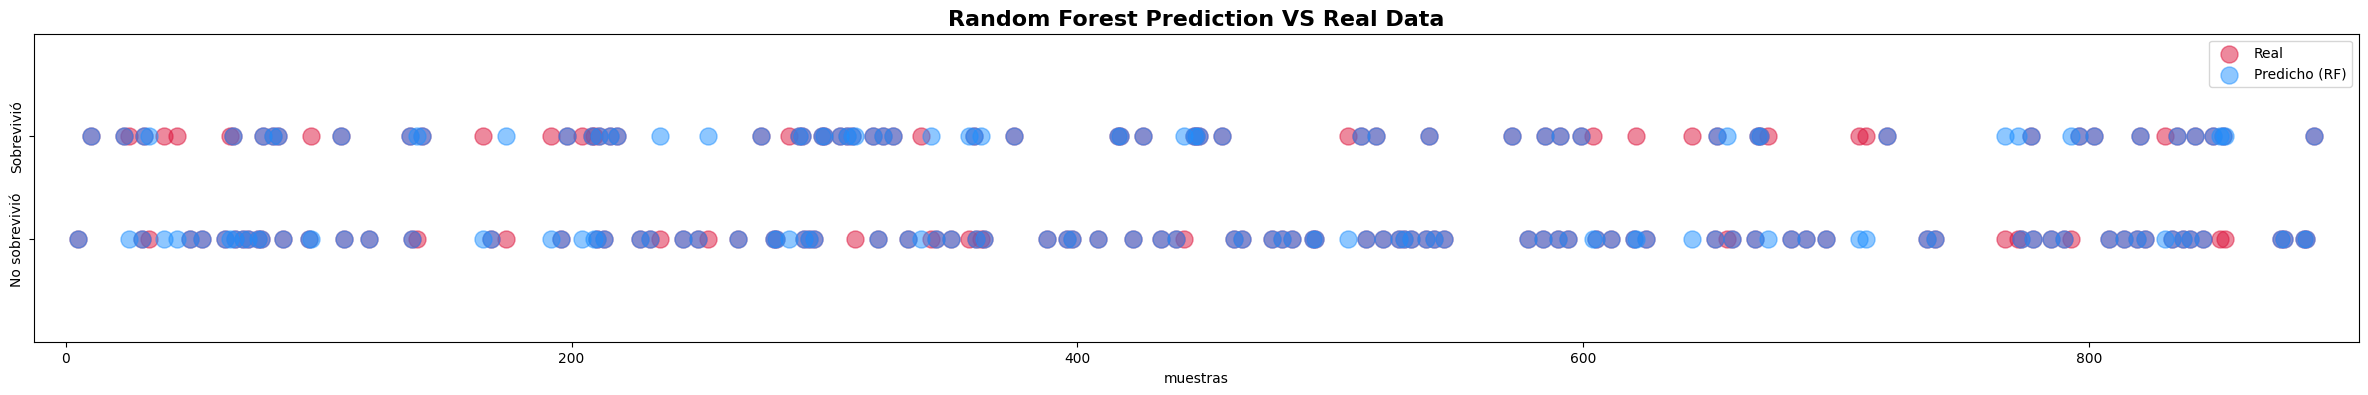

In [298]:
plt.figure(figsize=(30,4))
plt.scatter(y_test.index, y_test.values, s= 150, color= 'crimson', label= 'Real', alpha= 0.5)
plt.scatter(y_test.index, rf_pred, s=150,  color= 'dodgerblue', label= 'Predicho (RF)', alpha= 0.5)
# plt.scatter(y_test.index, best_rf_pred, s=150,  color= 'limegreen', label= 'Predicho (Best RF)', alpha= 0.3)
# plt.scatter(y_test.index, best_xgcv_pred, s=150,  color= 'darkviolet', label= 'Predicho (Best XGB)', alpha= 0.3)
plt.legend()
plt.yticks([0,1], ['No sobrevivió','Sobrevivió'])
plt.margins(y=1, x= 0.02)
plt.yticks(rotation=90, va='center', fontsize= 10)
plt.title('Random Forest Prediction VS Real Data', fontweight='bold',fontsize= 16)
plt.xlabel('muestras', fontsize=10)

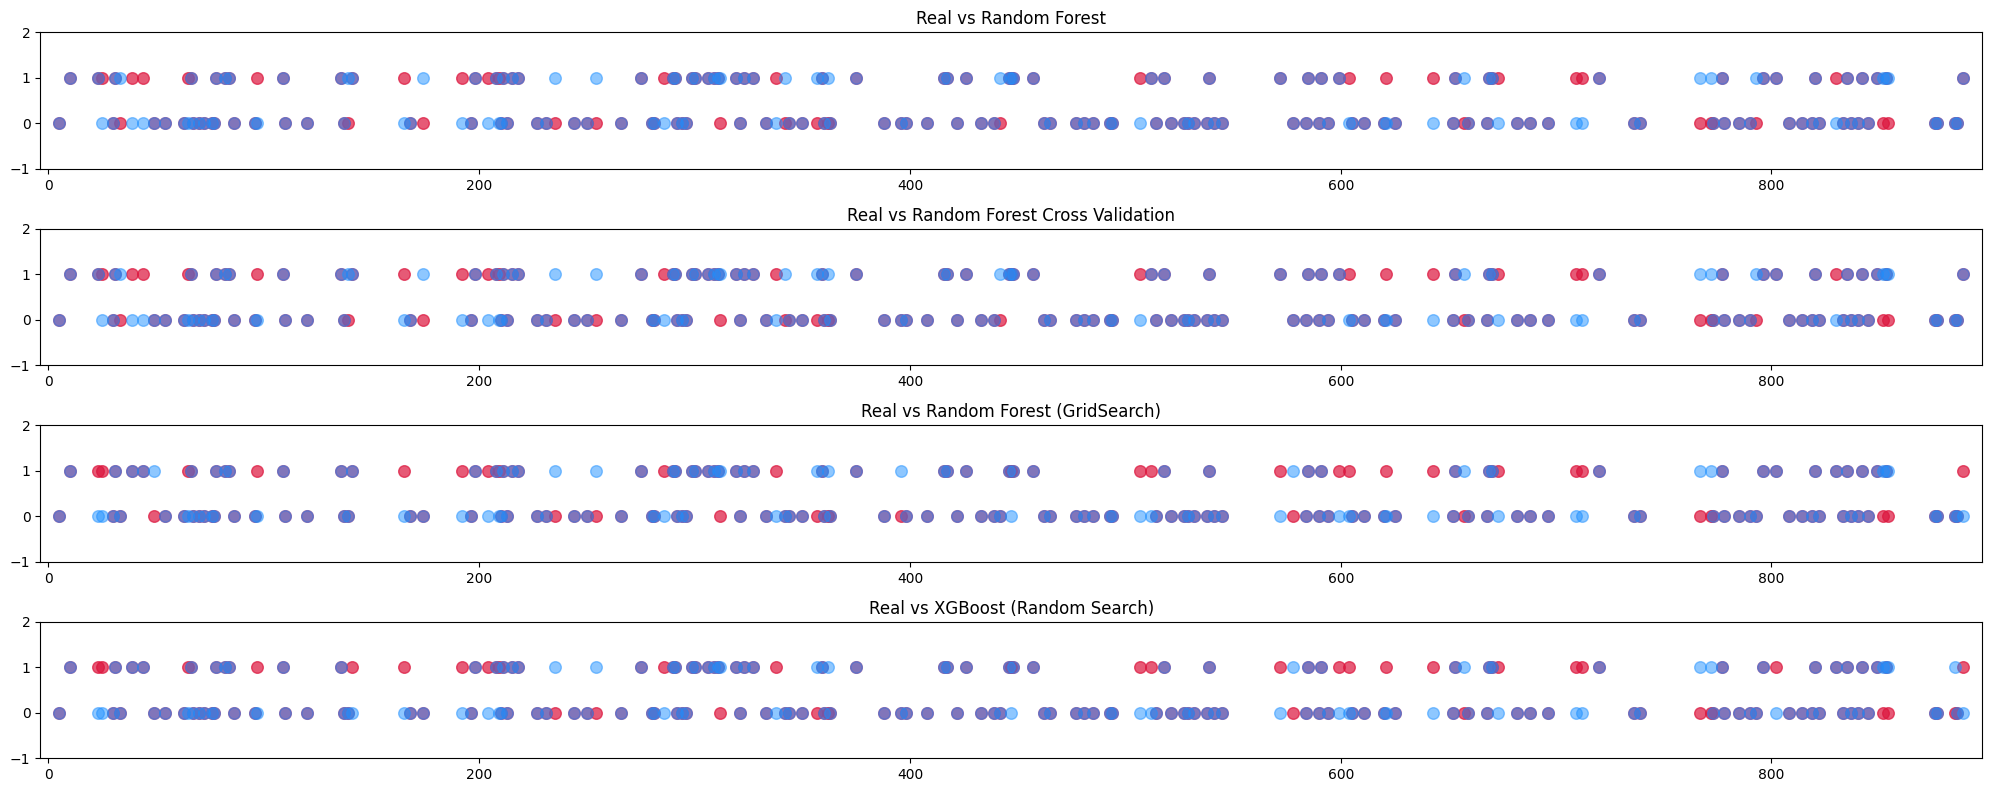

In [299]:
fig, axs = plt.subplots(4, 1, figsize=(20, 8),) # Crea una cuadrícula de 2x2
axs[0].scatter(y_test.index, y_test.values, s= 70, color= "crimson", label= 'Real', alpha= 0.7)
axs[1].scatter(y_test.index, y_test.values, s= 70, color= 'crimson', label= 'Real', alpha= 0.7)
axs[2].scatter(y_test.index, y_test.values, s= 70, color= 'crimson', label= 'Real', alpha= 0.7)
axs[3].scatter(y_test.index, y_test.values, s= 70, color= 'crimson', label= 'Real', alpha= 0.7)
axs[0].scatter(y_test.index, rf_pred, s= 70, color= "dodgerblue", label= 'Predicho (Random Forest)', alpha= 0.5) # Random Forest normal
axs[1].scatter(y_test.index, rf_cv_pred, s= 70, color= "dodgerblue", label= 'Predicho (Random Forest Cross Validation)', alpha= 0.5) # Random Forest CV
axs[2].scatter(y_test.index, best_rf_pred,  s= 70, color= 'dodgerblue', label= 'Predicho (Random Forest GridSearch)', alpha= 0.5) #Random Forest Grid Search
axs[3].scatter(y_test.index, best_xgcv_pred, s= 70, color= 'dodgerblue', label= 'Predicho (XGBoost RandomSearch)', alpha= 0.5) #XGBoost Random Search


axs[0].set_title('Real vs Random Forest')
axs[1].set_title('Real vs Random Forest Cross Validation')
axs[2].set_title('Real vs Random Forest (GridSearch)')
axs[3].set_title('Real vs XGBoost (Random Search)')

for ax in axs : 
    ax.set_ymargin(1)
    ax.set_xmargin(.01)

plt.tight_layout(pad=1)

plt.show()

In [300]:
print(randomcv.best_score_) #evaluacion de Random Search
print(gridsearch.best_score_) # evaluacion de Grid Search
print(rf_score_cv_acc.mean())
print(rf_acc_score)

0.8356741849699596
0.8286220821432089
0.8092335697696316
0.8044692737430168


In [301]:
Best_scores = {
    'Random Forest' : rf_acc_score,
    'Cross Validation' : rf_score_cv_acc,
    'Random Search' : randomcv.best_score_,
    'Grid Search' : gridsearch.best_score_,
}

scores = pd.DataFrame(Best_scores)
scores

,Random Forest,Cross Validation,Random Search,Grid Search
0,0.804469,0.782123,0.835674,0.828622
1,0.804469,0.808989,0.835674,0.828622
2,0.804469,0.848315,0.835674,0.828622
3,0.804469,0.780899,0.835674,0.828622
4,0.804469,0.825843,0.835674,0.828622


## 13. Resultados Finales
- Conclusiones
- Insights clave
- Limitaciones

### Conclusión

En este proyecto se realizó un análisis exploratorio y predictivo sobre el dataset Titanic con el objetivo de identificar los factores asociados a la supervivencia de los pasajeros y construir modelos de clasificación capaces de predecir dicho resultado.

Se llevó a cabo una etapa de limpieza y preparación de datos, incluyendo tratamiento de valores faltantes, transformación de variables categóricas y selección de variables relevantes. Posteriormente se entrenaron distintos modelos de Machine Learning, entre ellos Logistic Regression, Random Forest y XGBoost.

Tras comparar desempeño mediante métricas de clasificación y validación cruzada, los modelos basados en árboles mostraron mejor rendimiento general, destacando *XGboost*, Realizado con *Random Search* como la mejor alternativa por su capacidad de capturar relaciones no lineales entre variables.

Este proyecto permitió confirmar que variables como sexo, clase del boleto y edad tuvieron un impacto importante en la probabilidad de supervivencia.

### Insights Clave

#### 1. Sexo fue el factor más influyente

Las mujeres presentaron una tasa de supervivencia considerablemente mayor que los hombres, lo cual coincide con la política histórica de evacuación “women and children first”.

#### 2. Clase social importó mucho

Los pasajeros de primera clase tuvieron mayores probabilidades de sobrevivir que los de tercera clase, sugiriendo mejor acceso a zonas seguras, información o prioridad durante evacuación.

#### 3. Edad tuvo efecto parcial

Niños y pasajeros jóvenes mostraron mejores probabilidades de supervivencia que ciertos grupos adultos.

#### 4. Tarifa pagada se relacionó con supervivencia

Los pasajeros con boletos más costosos tendieron a sobrevivir más frecuentemente, posiblemente relacionado con clase socioeconómica.

#### 5. No todas las variables pesan igual

Variables como PassengerId tienen poco valor predictivo, mientras que Sex, Pclass y Fare sí aportan más información.

### Limitaciones 

- Dataset relativamente pequeño
- Variables limitadas
- Información histórica incompleta
- Posible sensibilidad a feature engineering adicional

## 14. Checklist Final
- [x] Datos limpios
- [x] EDA completo
- [ ] Features creados
- [x] Modelos evaluados
- [x] Resultados documentados